In [1]:
import sys
sys.path.append('../code')

import os

import jax
import jax.numpy as jnp
import jaxley as jx

import matplotlib.pyplot as plt
import numpy as np
from network_utils import make_network, set_train_parameters, simulate, gaussian_tuning, StimSynapse, get_currents, IonotropicSynapse
from memorycontext_cuesoma_contextsoma import get_prior_dict
from jax import config
import pickle
from networkx import connected_watts_strogatz_graph, adjacency_matrix,gaussian_random_partition_graph
# from jaxley_mech.synapses.destexhe98 import AMPA, GABAa, GABAb, NMDA

import pandas as pd
import seaborn as sns

from neurodsp.spectral import compute_spectrum
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.decomposition import PCA

from tqdm import tqdm

config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
# config.update("jax_platform_name", "gpu")

/users/ntolley/.conda/envs/jaxley/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path =  '/users/ntolley/data/ntolley/dendractor/random_initialization_memorycontext'
file_list = os.listdir(data_path)

random_init_dict = dict()
for file_idx in tqdm(range(len(file_list))):
    with open(f'{data_path}/{file_list[file_idx]}', 'rb') as f:
        res_dict = pickle.load(f)
    
    random_init_dict[res_dict['name']] = res_dict

100%|██████████| 7/7 [00:06<00:00,  1.02it/s]


In [5]:
print(list(random_init_dict.keys()))

['cuedend_contextdend_celldend', 'cuedend_contextdend', 'cuedend_contextsoma', 'cuesoma_contextdend', 'cuesoma_contextsoma_celldend', 'cuesoma_contextsoma_cellsoma', 'cuesoma_contextsoma']


In [10]:
res_dict = random_init_dict['cuesoma_contextsoma']
# res_dict = random_init_dict['cuedend_contextdend']

name = res_dict['name']
output_array = res_dict['output_array']
targets = res_dict['targets']
gid_ranges = res_dict['gid_ranges']
input_list = res_dict['input_list']
num_cond = input_list.shape[0]
print(name)

cuesoma_contextsoma


In [11]:
t_max = 2000
dt = 0.25 # simulation output downsampled by factor of 10
fs = (1/dt) * 1e3
time_vec = np.arange(0, t_max, dt)
downsample_factor = 10
burn_in = int(8000 / downsample_factor)

In [12]:
rate_gids = list(gid_ranges['E_rate'])
rates = output_array[:, rate_gids, :]

x_train = list()
for sim_idx in range(0, output_array.shape[0], num_cond):
    temp_list = list()
    for cond_idx in range(num_cond):
        temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
    x_train.append(np.concatenate(temp_list, axis=1).T)


num_model_sims = 15

error_list = list()
model = Ridge(alpha=2.0)
rate_fit = np.concatenate([x[burn_in:, :] for x in x_train[:num_model_sims]])
target_fit = np.concatenate([targets[burn_in:, :] for _ in range(num_model_sims)])
model.fit(rate_fit, target_fit)

# for sim_idx in range(num_model_sims, len(x_train)):
for sim_idx in range(len(x_train)):
    rate_pred = x_train[sim_idx]
    y_pred = model.predict(rate_pred[burn_in:, :])


    error = np.mean(np.square(targets[burn_in:, :] - y_pred))
    error_list.append(error)

print(error_list)

[0.1511895838247862, 0.14157234660820883, 0.147956422012835, 0.1472365212636212, 0.147032609726103, 0.15768801434951593, 0.17200252563132307, 0.14424013050363255, 0.1396360565276087, 0.15187019367195956, 0.14421333940354375, 0.140863797377772, 0.14282462424450304, 0.1460257160922707, 0.14243176186486028, 0.1623588481992859, 0.15681564851198568, 0.15524319611434506, 0.15692786177864385, 0.14570158030604732]


/tmp/ipykernel_287960/3360209264.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = axes[2].set_xticklabels(labels=axes[2].get_xticklabels(), fontsize=ticksize)


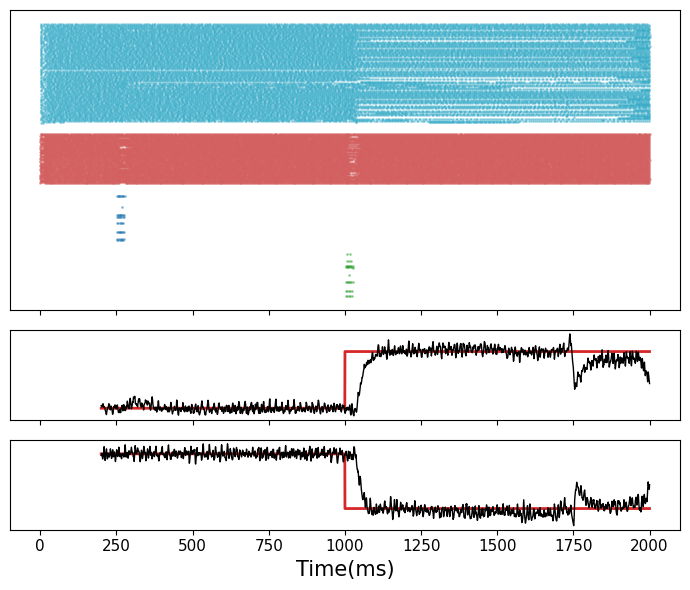

In [116]:
sim_idx = 2
random_init_idx = 17

sim_idx += random_init_idx * num_cond
x_pred = output_array[sim_idx, gid_ranges['E_rate'], :].T
y_pred = model.predict(x_pred[burn_in:, :])

labelsize = 15
ticksize = 11
threshold = 0.0

spike_color_dict = {'E': '#37abc8', 'I': '#d35f5f', 'context': '#1f77b4', 'cue': '#2ca02c'}

fig, axes = plt.subplots(3,1,figsize=(7,6), sharex=True, height_ratios=[1,0.3,0.3])
s = output_array[sim_idx, :]
above_threshold = s > threshold
spike_gids, spike_times = np.where(np.diff(above_threshold.astype(int), axis=1) == 1)

for type_idx, (name, cell_range) in enumerate(gid_ranges.items()):
    if name not in ['output', 'E_rate', 'I_rate']:
        mask = np.isin(spike_gids, cell_range)
        axes[0].scatter(spike_times[mask] * dt, -spike_gids[mask] - type_idx * 10, label=name, s=1, alpha=0.4, color=spike_color_dict[name])

# axes[0].set_xticks([])
# axes[1].set_xticks([])

axes[0].set_yticks([])
axes[1].set_yticks([])
axes[2].set_yticks([])

axes[1].plot(time_vec[burn_in-1:], targets[burn_in:y_pred.shape[0]+burn_in, 1] * -1, color='C3', linewidth=2)
axes[1].plot(time_vec[burn_in-1:], y_pred[:,1], color='k', linewidth=1)

axes[2].plot(time_vec[burn_in-1:], targets[burn_in:y_pred.shape[0]+burn_in, 0], color='C3', linewidth=2)
axes[2].plot(time_vec[burn_in-1:], y_pred[:,0], color='k', linewidth=1)

axes[2].set_xlabel('Time(ms)', fontsize=labelsize)
_ = axes[2].set_xticklabels(labels=axes[2].get_xticklabels(), fontsize=ticksize)
plt.tight_layout()
plt.savefig('memorycontext_raster.svg')


In [19]:
explained_var_dict = dict()
for name in tqdm(random_init_dict.keys()):
    output_array = random_init_dict[name]['output_array']
    x_train = list()
    for sim_idx in range(0, output_array.shape[0], num_cond):
        temp_list = list()
        for cond_idx in range(num_cond):
            temp_list.append(output_array[sim_idx + cond_idx, gid_ranges['E_rate'], :])
        x_train.append(np.concatenate(temp_list, axis=1).T)

    pca = PCA()
    pca.fit(np.concatenate(x_train))
    explained_var_dict[name] = pca.explained_variance_ratio_

100%|██████████| 7/7 [00:07<00:00,  1.10s/it]


Text(0, 0.5, 'Total Explained Variance (%)')

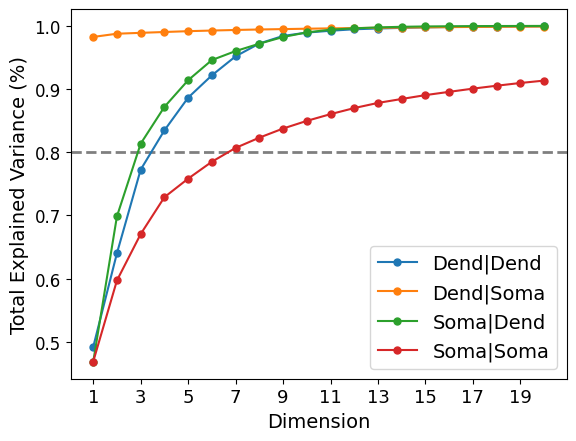

In [59]:
cond_names = {'cuedend_contextdend': 'Dend|Dend',
              'cuedend_contextsoma': 'Dend|Soma',
              'cuesoma_contextdend': 'Soma|Dend',
              'cuesoma_contextsoma': 'Soma|Soma'}

max_dim = 20
ticksize = 13
labelsize = 14
color_offset = 0
plt.figure()

for line_idx, (name, cond_label) in enumerate(cond_names.items()):
    exp_var = explained_var_dict[name]
    plt.plot(range(1, max_dim + 1), np.cumsum(exp_var[:max_dim]),
             label=cond_label, marker='.', markersize=10, color=f'C{line_idx}')
plt.legend(fontsize=labelsize)
plt.axhline(0.8, color='k', linestyle='--', linewidth=2, alpha=0.5, zorder=-10)
_ = plt.xticks(range(1, max_dim+1,2), labels=range(1, max_dim+1,2), fontsize=ticksize)
plt.yticks(fontsize=12)
plt.xlabel('Dimension', fontsize=labelsize)
plt.ylabel('Total Explained Variance (%)', fontsize=labelsize)

Text(0, 0.5, 'Total Explained Variance (%)')

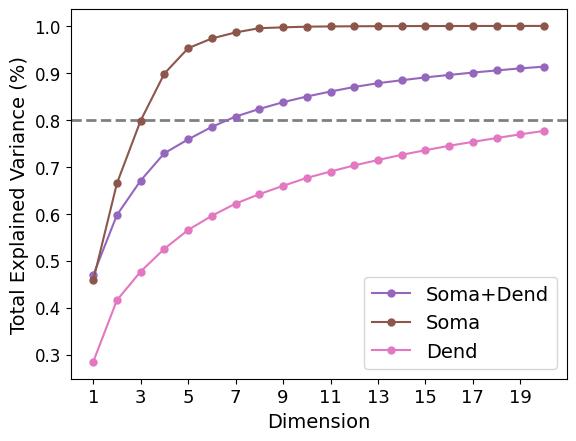

In [67]:
cond_names= {'cuesoma_contextsoma': 'Soma+Dend',
             'cuesoma_contextsoma_cellsoma': 'Soma',
             'cuesoma_contextsoma_celldend': 'Dend'}

color_offset = 4
plt.figure()

for line_idx, (name, cond_label) in enumerate(cond_names.items()):
    exp_var = explained_var_dict[name]
    plt.plot(range(1, max_dim + 1), np.cumsum(exp_var[:max_dim]),
             label=cond_label, marker='.', markersize=10, color=f'C{line_idx+color_offset}')
plt.legend(fontsize=labelsize)
plt.axhline(0.8, color='k', linestyle='--', linewidth=2, alpha=0.5, zorder=-10)
_ = plt.xticks(range(1, max_dim+1,2), labels=range(1, max_dim+1,2), fontsize=ticksize)
plt.yticks(fontsize=12)
plt.xlabel('Dimension', fontsize=labelsize)
plt.ylabel('Total Explained Variance (%)', fontsize=labelsize)
